Dropdown(description='Ticker:', options=('AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA'), value='AAPL')

Failed to get ticker 'AAPL' reason: Expecting value: line 1 column 1 (char 0)


[*********************100%%**********************]  1 of 1 completed


1 Failed download:
['AAPL']: Exception('%ticker%: No timezone found, symbol may be delisted')


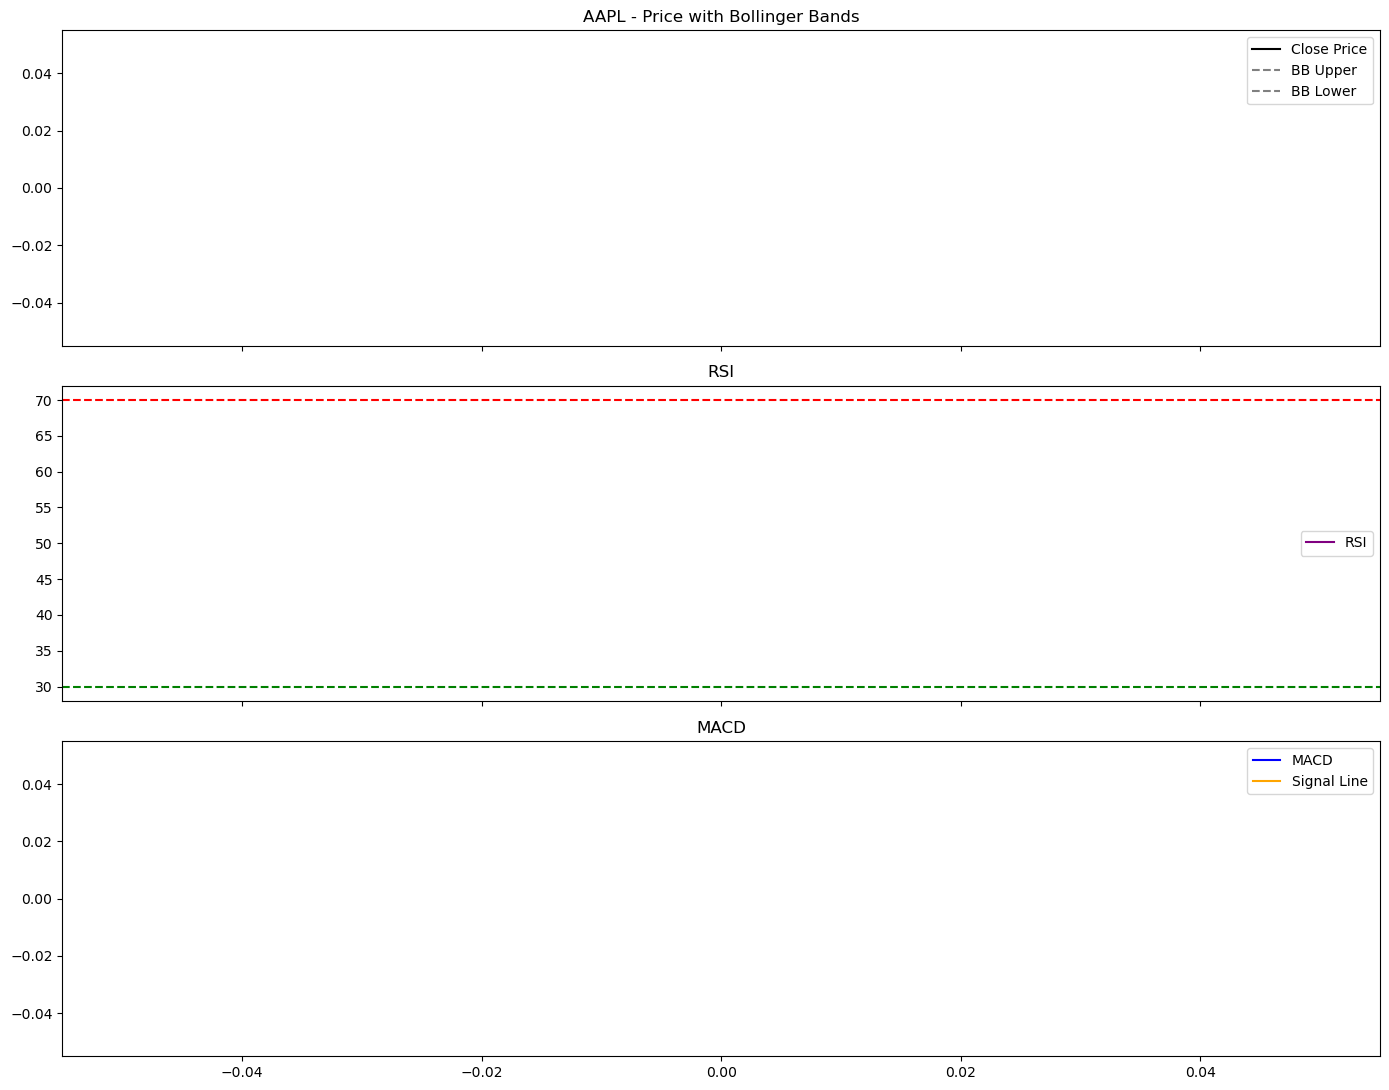

In [10]:
# 📊 Interactive Technical Analysis with RSI, MACD, and Bollinger Bands

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# -- Widget to select ticker --
ticker_input = widgets.Dropdown(
    options=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA'],
    value='AAPL',
    description='Ticker:'
)

display(ticker_input)

# -- Functions --
def calculate_rsi(data, period=14):
    delta = data['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    data['RSI'] = rsi
    return data

def calculate_macd(data):
    ema12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema26 = data['Close'].ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()
    data['MACD'] = macd
    data['Signal'] = signal
    return data

def calculate_bollinger_bands(data, window=20):
    sma = data['Close'].rolling(window=window).mean()
    std = data['Close'].rolling(window=window).std()
    data['BB_Upper'] = sma + 2 * std
    data['BB_Lower'] = sma - 2 * std
    return data

def plot_technical_indicators(data, ticker):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

    ax1.plot(data['Close'], label='Close Price', color='black')
    ax1.plot(data['BB_Upper'], label='BB Upper', linestyle='--', color='gray')
    ax1.plot(data['BB_Lower'], label='BB Lower', linestyle='--', color='gray')
    ax1.set_title(f"{ticker} - Price with Bollinger Bands")
    ax1.legend()

    ax2.plot(data['RSI'], label='RSI', color='purple')
    ax2.axhline(70, color='red', linestyle='--')
    ax2.axhline(30, color='green', linestyle='--')
    ax2.set_title('RSI')
    ax2.legend()

    ax3.plot(data['MACD'], label='MACD', color='blue')
    ax3.plot(data['Signal'], label='Signal Line', color='orange')
    ax3.set_title('MACD')
    ax3.legend()

    plt.tight_layout()
    plt.show()

# -- Load and analyze data --
ticker = ticker_input.value
df = yf.download(ticker, start="2024-01-01", end="2025-01-01")
df = calculate_rsi(df)
df = calculate_macd(df)
df = calculate_bollinger_bands(df)
plot_technical_indicators(df, ticker)


In [12]:
!pip install yfinance


In [14]:
!conda install -c conda-forge yfinance --yes


Jupyter detected...
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\johnl\anaconda3

  added / updated specs:
    - yfinance


The following NEW packages will be INSTALLED:

  yfinance           conda-forge/noarch::yfinance-0.2.28-pyhd8ed1ab_0 



Preparing transaction: done
Verifying transaction: done
Executing transaction: done


Dropdown(description='Ticker:', options=('AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA'), value='AAPL')

Failed to get ticker 'AAPL' reason: Expecting value: line 1 column 1 (char 0)


[*********************100%%**********************]  1 of 1 completed


1 Failed download:
['AAPL']: Exception('%ticker%: No timezone found, symbol may be delisted')


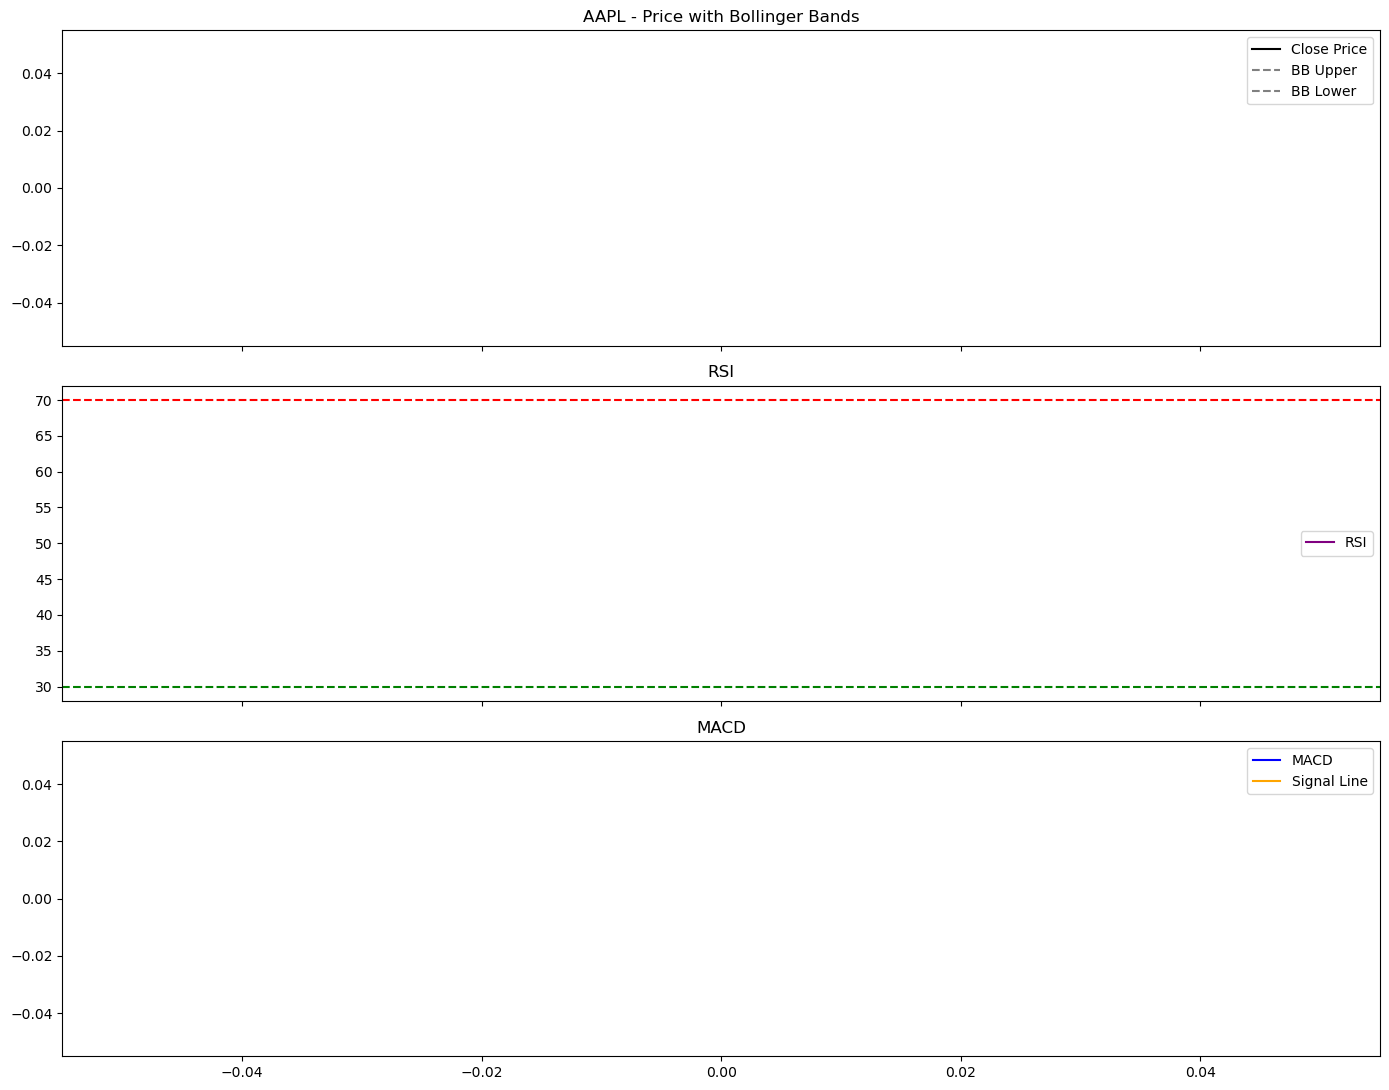

In [16]:
# 📊 Interactive Technical Analysis with RSI, MACD, and Bollinger Bands

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# -- Widget to select ticker --
ticker_input = widgets.Dropdown(
    options=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA'],
    value='AAPL',
    description='Ticker:'
)

display(ticker_input)

# -- Functions --
def calculate_rsi(data, period=14):
    delta = data['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    data['RSI'] = rsi
    return data

def calculate_macd(data):
    ema12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema26 = data['Close'].ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()
    data['MACD'] = macd
    data['Signal'] = signal
    return data

def calculate_bollinger_bands(data, window=20):
    sma = data['Close'].rolling(window=window).mean()
    std = data['Close'].rolling(window=window).std()
    data['BB_Upper'] = sma + 2 * std
    data['BB_Lower'] = sma - 2 * std
    return data

def plot_technical_indicators(data, ticker):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

    ax1.plot(data['Close'], label='Close Price', color='black')
    ax1.plot(data['BB_Upper'], label='BB Upper', linestyle='--', color='gray')
    ax1.plot(data['BB_Lower'], label='BB Lower', linestyle='--', color='gray')
    ax1.set_title(f"{ticker} - Price with Bollinger Bands")
    ax1.legend()

    ax2.plot(data['RSI'], label='RSI', color='purple')
    ax2.axhline(70, color='red', linestyle='--')
    ax2.axhline(30, color='green', linestyle='--')
    ax2.set_title('RSI')
    ax2.legend()

    ax3.plot(data['MACD'], label='MACD', color='blue')
    ax3.plot(data['Signal'], label='Signal Line', color='orange')
    ax3.set_title('MACD')
    ax3.legend()

    plt.tight_layout()
    plt.show()

# -- Load and analyze data --
ticker = ticker_input.value
df = yf.download(ticker, start="2024-01-01", end="2025-01-01")
df = calculate_rsi(df)
df = calculate_macd(df)
df = calculate_bollinger_bands(df)
plot_technical_indicators(df, ticker)


In [18]:
# Add these widgets near your ticker dropdown
rsi_slider = widgets.IntSlider(value=14, min=5, max=30, step=1, description='RSI Period:')
bb_slider = widgets.IntSlider(value=20, min=10, max=50, step=1, description='BB Window:')

display(rsi_slider, bb_slider)


IntSlider(value=14, description='RSI Period:', max=30, min=5)

IntSlider(value=20, description='BB Window:', max=50, min=10)

In [20]:
df = calculate_rsi(df, period=rsi_slider.value)
df = calculate_bollinger_bands(df, window=bb_slider.value)
